In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics -q

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.6 MB/s eta 0:00:00


In [ ]:
import os

base = "/content/drive/MyDrive/IPD"
for root, dirs, files in os.walk(base):
    depth = root.replace(base, "").count(os.sep)
    if depth <= 3:
        print(("  " * depth) + os.path.basename(root) + "/")

IPD/
  dataset/
    train/
      images/
      labels/
    valid/
      labels/
      images/
    Ftir/
      microplastic-hsi-ilab/
      microplastic-hsi-envi/
      microplastic-hsi-mat/
  .ipynb_checkpoints/
  data/
  Yolov8/
    Unified_MicroplasticDetect_Dataset.v2i.yolov8/
      valid/
      test/
      train/


In [ ]:
import os

# Adjust this if your folder name inside "yolo v8" differs
DATASET_PATH = "/content/drive/MyDrive/IPD/Yolov8/Unified_MicroplasticDetect_Dataset.v2i.yolov8"

print(os.listdir(DATASET_PATH))

['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'valid', 'test', 'train']


In [ ]:
print(os.listdir(DATASET_PATH))
data_yaml_path = os.path.join(DATASET_PATH, "data.yaml")
print(os.path.exists(data_yaml_path))
if os.path.exists(data_yaml_path):
    with open(data_yaml_path) as f:
        print(f.read())

['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'valid', 'test', 'train']
True
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['Beams', 'Foams', 'Microplastic']

roboflow:
  workspace: kunsh-kaul
  project: unified_microplasticdetect_dataset
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/kunsh-kaul/unified_microplasticdetect_dataset/dataset/2


In [ ]:
import yaml, os

fixed_yaml = {
    "train": os.path.join(DATASET_PATH, "train", "images"),
    "val": os.path.join(DATASET_PATH, "valid", "images"),
    "test": os.path.join(DATASET_PATH, "test", "images"),
    "nc": 3,
    "names": ["Beams", "Foams", "Microplastic"]
}

DATA_YAML = "/content/data_fixed.yaml"
with open(DATA_YAML, "w") as f:
    yaml.dump(fixed_yaml, f)

with open(DATA_YAML) as f:
    print(f.read())

names:
- Beams
- Foams
- Microplastic
nc: 3
test: /content/drive/MyDrive/IPD/Yolov8/Unified_MicroplasticDetect_Dataset.v2i.yolov8/test/images
train: /content/drive/MyDrive/IPD/Yolov8/Unified_MicroplasticDetect_Dataset.v2i.yolov8/train/images
val: /content/drive/MyDrive/IPD/Yolov8/Unified_MicroplasticDetect_Dataset.v2i.yolov8/valid/images



In [ ]:
for split in ["train", "valid", "test"]:
    img_dir = os.path.join(DATASET_PATH, split, "images")
    lbl_dir = os.path.join(DATASET_PATH, split, "labels")
    print(split, "images:", len(os.listdir(img_dir)), "labels:", len(os.listdir(lbl_dir)))

train images: 5678 labels: 5678
valid images: 490 labels: 490
test images: 275 labels: 275


In [ ]:
!pip install ultralytics -q

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=640,
    batch=16,
    project="/content/runs",
    name="microplastic_yolov8"
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_fixed.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freez

In [ ]:
import shutil

DATASET_PATH = "/content/drive/MyDrive/IPD/Yolov8/Unified_MicroplasticDetect_Dataset.v2i.yolov8"

shutil.copytree(DATASET_PATH, "/content/local_dataset")
print("Copy done")

Copy done


In [ ]:
import yaml, os

LOCAL_DATASET = "/content/local_dataset"

fixed_yaml = {
    "train": os.path.join(LOCAL_DATASET, "train", "images"),
    "val": os.path.join(LOCAL_DATASET, "valid", "images"),
    "test": os.path.join(LOCAL_DATASET, "test", "images"),
    "nc": 3,
    "names": ["Beams", "Foams", "Microplastic"]
}

DATA_YAML = "/content/data_fixed.yaml"
with open(DATA_YAML, "w") as f:
    yaml.dump(fixed_yaml, f)

print(open(DATA_YAML).read())

names:
- Beams
- Foams
- Microplastic
nc: 3
test: /content/local_dataset/test/images
train: /content/local_dataset/train/images
val: /content/local_dataset/valid/images



In [ ]:
for split in ["train", "valid", "test"]:
    img_dir = os.path.join(LOCAL_DATASET, split, "images")
    lbl_dir = os.path.join(LOCAL_DATASET, split, "labels")
    print(split, "images:", len(os.listdir(img_dir)), "labels:", len(os.listdir(lbl_dir)))

train images: 5678 labels: 5678
valid images: 490 labels: 490
test images: 275 labels: 275


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=640,
    batch=16,
    project="/content/runs",
    name="microplastic_yolov8"
)

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_fixed.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=microplastic_yolov8-2, nbs=64, nms=None, opset=None,

In [ ]:
import shutil, os

dest_dir = "/content/drive/MyDrive/IPD_outputs/microplastic_yolov8"
os.makedirs(dest_dir, exist_ok=True)
shutil.copytree("/content/runs/microplastic_yolov8-2", dest_dir, dirs_exist_ok=True)
print("Copied to:", dest_dir)

Copied to: /content/drive/MyDrive/IPD_outputs/microplastic_yolov8


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/microplastic_yolov8-2/weights/best.pt")

results = model.predict(
    source="/content/local_dataset/test/images",
    save=True,
    conf=0.25
)
print("Predictions saved to:", results[0].save_dir)


image 1/275 /content/local_dataset/test/images/111_jpg.rf.494adebdc9f6d1cafa060a76cedf004b.jpg: 640x640 13 Microplastics, 28.4ms
image 2/275 /content/local_dataset/test/images/111_jpg.rf.bd985daa259b860c251b7d025d641351.jpg: 640x640 13 Microplastics, 16.1ms
image 3/275 /content/local_dataset/test/images/116_jpg.rf.d0146214fc764ea218bdae24512068d7.jpg: 640x640 14 Microplastics, 24.3ms
image 4/275 /content/local_dataset/test/images/117_jpg.rf.85dacbbac001abcafd61187a892b35a1.jpg: 640x640 16 Microplastics, 30.9ms
image 5/275 /content/local_dataset/test/images/11B10_jpg.rf.3f583c29e5d7d9a41b94d282130bc64a.jpg: 640x384 (no detections), 156.6ms
image 6/275 /content/local_dataset/test/images/121_jpg.rf.b61e85cff66eb6b4768c276b88e5d69c.jpg: 640x640 10 Microplastics, 52.3ms
image 7/275 /content/local_dataset/test/images/123_jpg.rf.92930ef14da9f2754bfb1682ffe09c85.jpg: 640x640 24 Microplastics, 37.6ms
image 8/275 /content/local_dataset/test/images/124_jpg.rf.55fd9e51f0ccb620c07cad09a3cd74bd.jpg

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/microplastic_yolov8-2/weights/best.pt")

metrics = model.val(data="/content/data_fixed.yaml", plots=True)

# Per-class breakdown
print("Class names:", metrics.names)
print("Precision per class:", metrics.box.p)
print("Recall per class:", metrics.box.r)
print("mAP50 per class:", metrics.box.ap50)
print("mAP50-95 per class:", metrics.box.ap)

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 727.1±194.8 MB/s, size: 32.1 KB)
val: Scanning /content/local_dataset/valid/labels.cache... 490 images, 50 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 490/490 114.2Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1027, len(boxes) = 4065. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 3.3it/s 9.4s
                   all        490       4065      0.898      0.884      0.913      0.689
                 Beams         23        352      0.995          1      0.995      0.855
                 Foams         62 

In [ ]:
print(metrics.save_dir)

/content/runs/detect/val


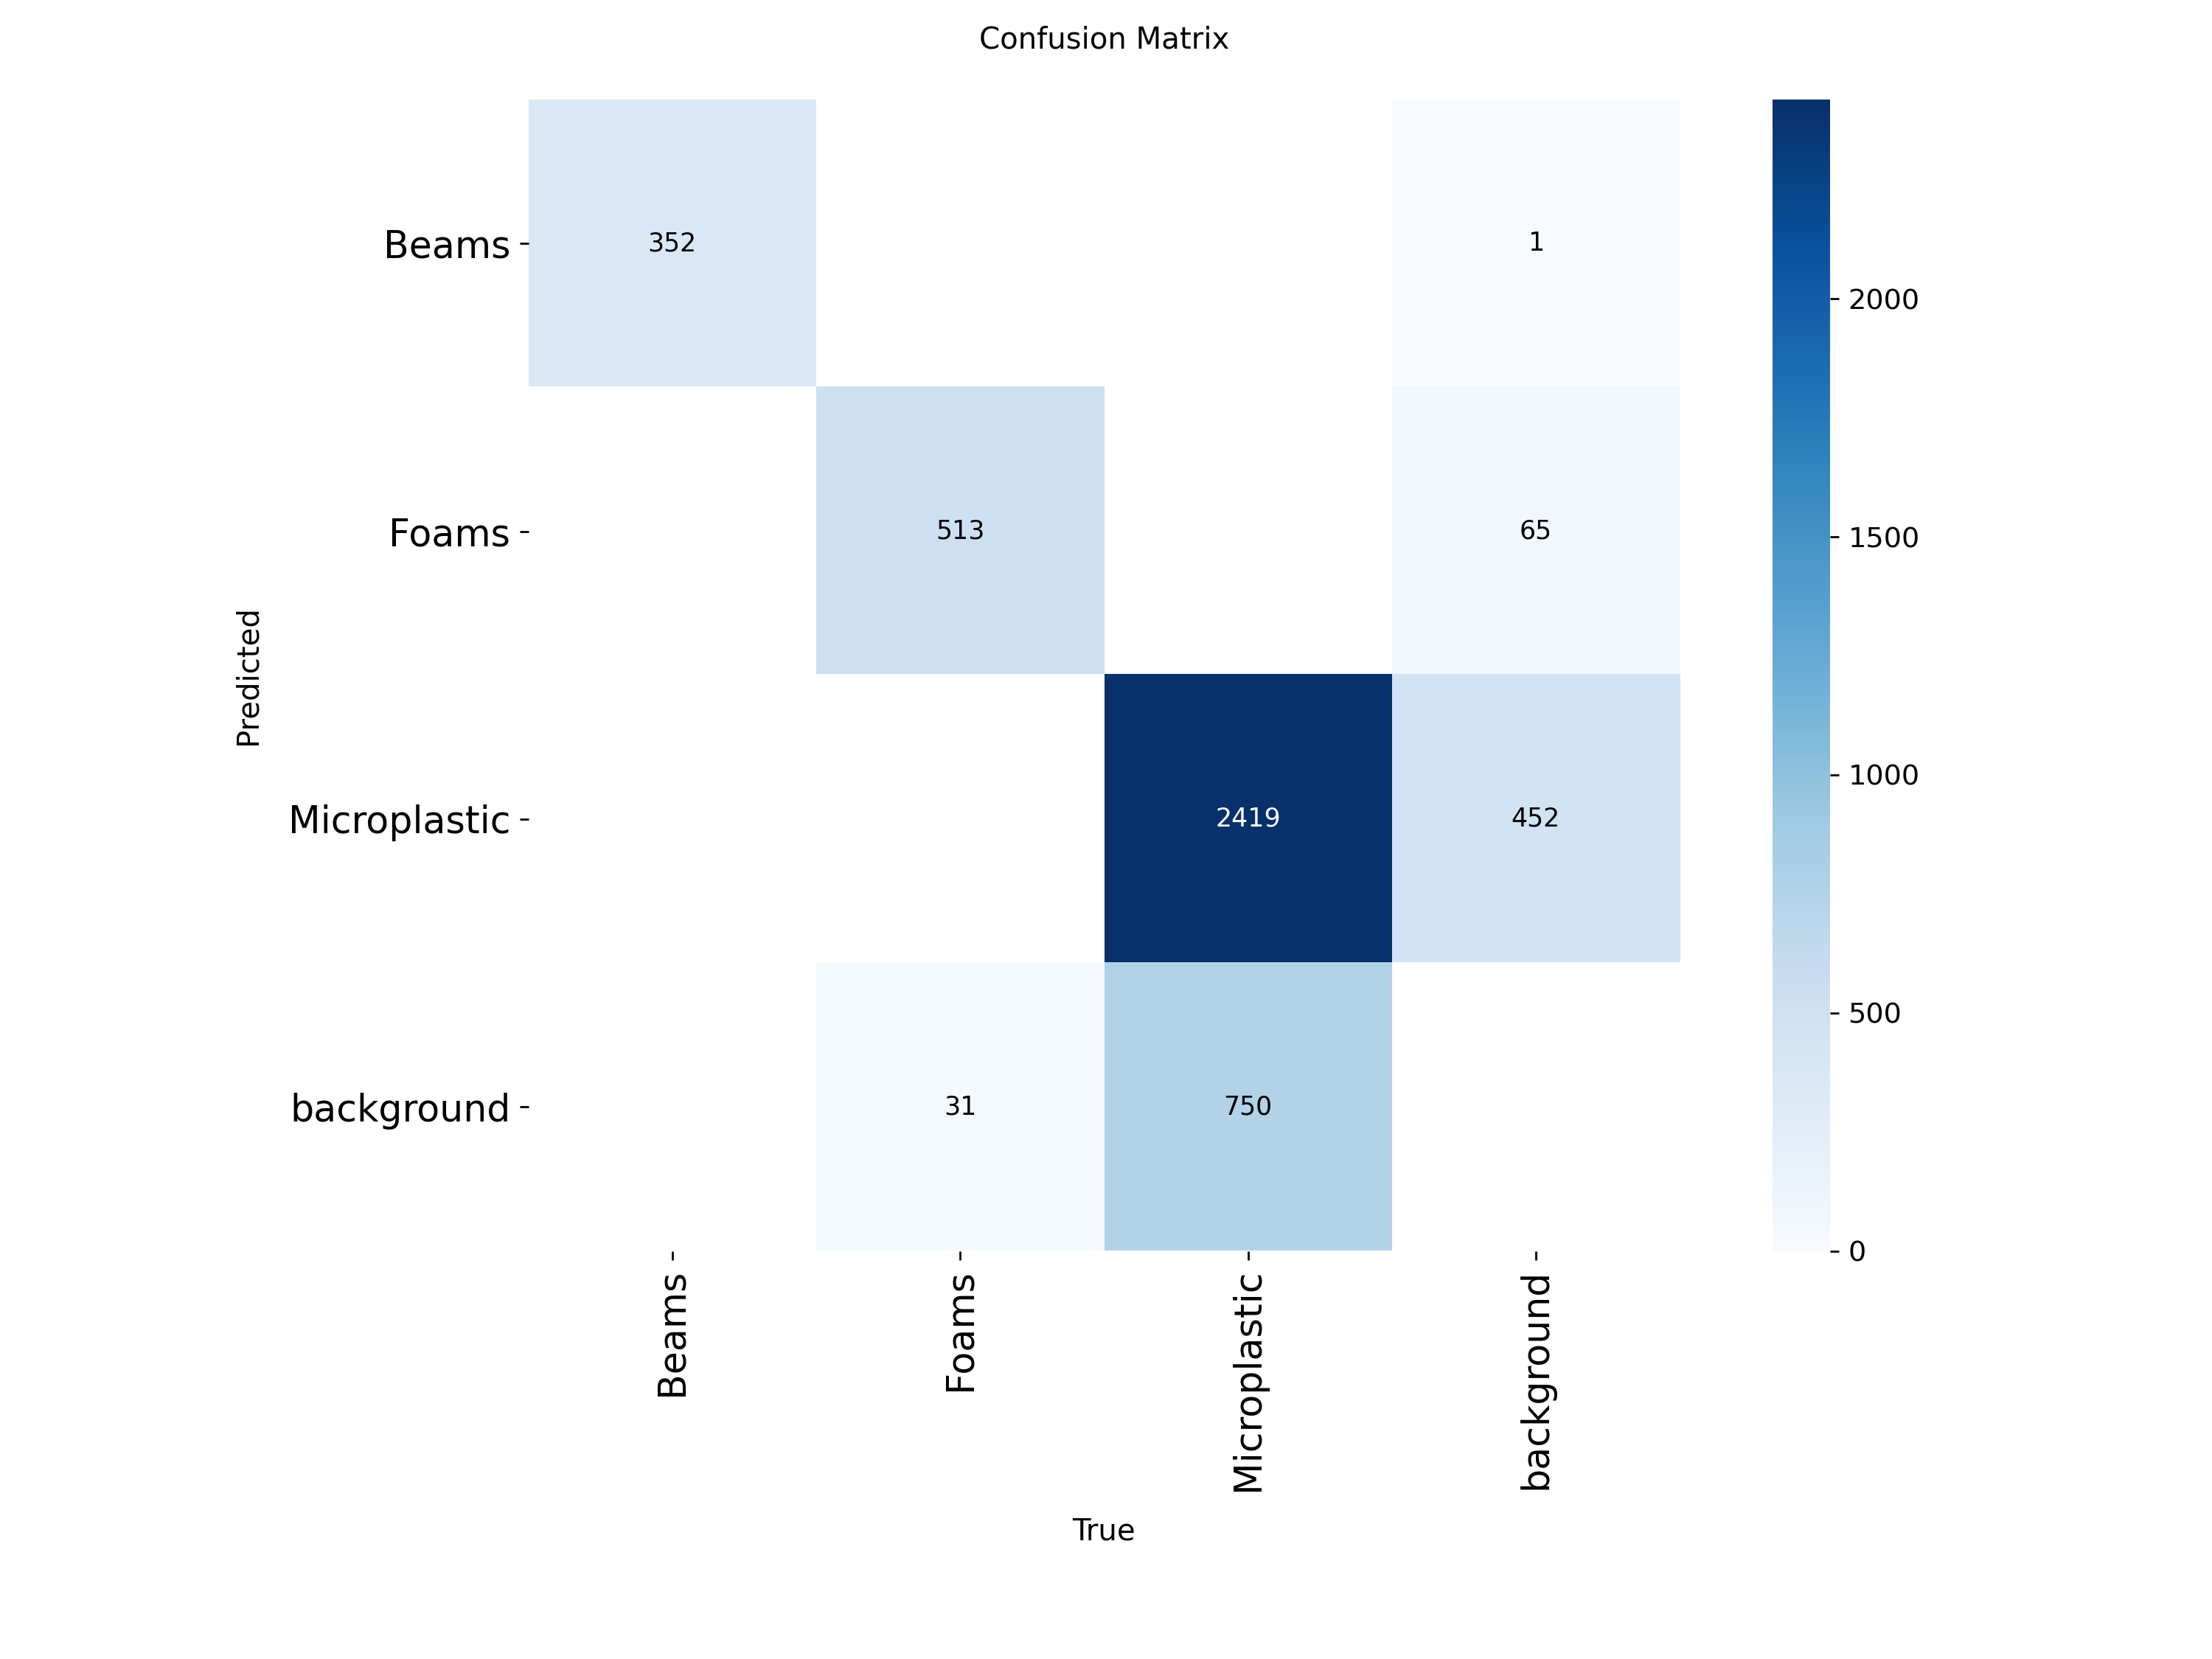

In [ ]:
from IPython.display import Image, display
import os

cm_path = os.path.join(str(metrics.save_dir), "confusion_matrix.png")
display(Image(filename=cm_path))